# Heart Failure Clinical Records — Machine Learning Analysis

This notebook explores the Heart Failure Clinical Records dataset and builds classification models to predict the `DEATH_EVENT` outcome. The analysis covers data preparation, exploratory analysis, model development, and evaluation.

**Objective:**

* Understand the structure
of the dataset

* Check data quality

* Explore important variables

* Build classification models

* Compare their performance using multiple metrics

**Dataset Overview**

The dataset contains clinical information for 299 patients. The input variables describe factors such as age, medical conditions, laboratory measurements, smoking status and follow-up time. The target variable is `DEATH_EVENT`, which indicates the outcome being predicted.

`DEATH_EVENT = 0` represents no recorded death event, while `DEATH_EVENT = 1` represents a death event.



In [73]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
        precision_score,
            recall_score,
                f1_score,
                    roc_auc_score,
                        classification_report,
                            confusion_matrix,
                                RocCurveDisplay
                                )


# 2. Loading and Inspecting the Data

I first load the dataset into a pandas DataFrame and inspect its dimensions and column information. This gives an initial understanding of the data before any analysis is performed.

In [74]:
# Optional Kaggle download:
# 1. Download the CSV from Kaggle.
# 2. Put it in the same folder as this notebook.
# 3. Change DATA_PATH if necessary.

DATA_PATH = "heart_failure_clinical_records_dataset.csv"

import os
if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
else:
    # Fallback: use a public GitHub mirror of the same UCI dataset.
    url = "https://raw.githubusercontent.com/andrewmvd/heart-failure-clinical-data/master/heart_failure_clinical_records_dataset.csv"
    df = pd.read_csv(url)

df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


**Libraries**

Pandas and NumPy are used for data handling, Matplotlib and Seaborn for visualisation, and Scikit-learn for preprocessing, modelling and evaluation.

In [75]:
print("Dataset shape:", df.shape)

Dataset shape: (299, 13)


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [77]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())



Missing values:


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0



Duplicate rows: 0


# 3. Data Quality Check

Before moving to exploratory analysis, I checked the dataset for missing values, duplicate observations and the data type of each column. These checks help confirm whether the dataset requires additional cleaning.

### 3.1 Checking Data Types

The data type of each column is examined to confirm that the variables have been imported in an appropriate format.

In [78]:
df.dtypes

,0
age,float64
anaemia,int64
creatinine_phosphokinase,int64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


## 4. Descriptive Statistics

The summary statistics provide a quick view of the typical values and ranges in the dataset. They also show that the variables are measured on different scales, which is important to consider during model preparation.

In [79]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


### Observation

There are 203 records with `DEATH_EVENT = 0` and 96 records with `DEATH_EVENT = 1`. Since the two classes are not evenly distributed, I will use more than accuracy to evaluate the classification models.

,count
DEATH_EVENT,
0,203
1,96


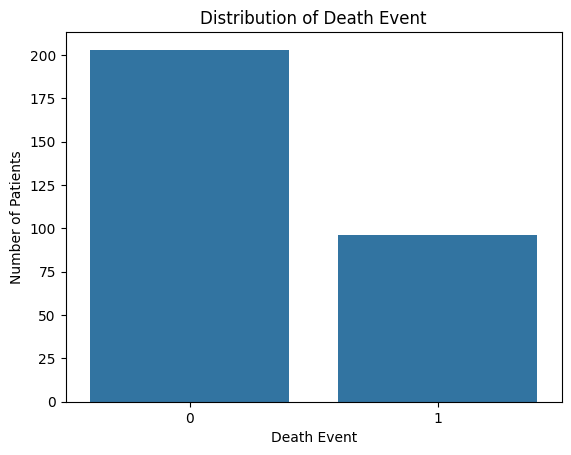

In [80]:
# Target distribution
display(df["DEATH_EVENT"].value_counts())

sns.countplot(data=df, x="DEATH_EVENT")
plt.title("Distribution of Death Event")
plt.xlabel("Death Event")
plt.ylabel("Number of Patients")
plt.show()


**Target Distribution**

The target variable is not evenly distributed between the two classes. Therefore, accuracy alone may not give a complete picture of model performance. I will also consider precision, recall, F1-score and ROC-AUC.

The dataset contains 203 observations in class 0 and 96 observations in class 1.

# 5. Distribution of Features

Histograms are used to see how the numerical variables are distributed. They also make it easier to notice variables with highly concentrated or skewed values.

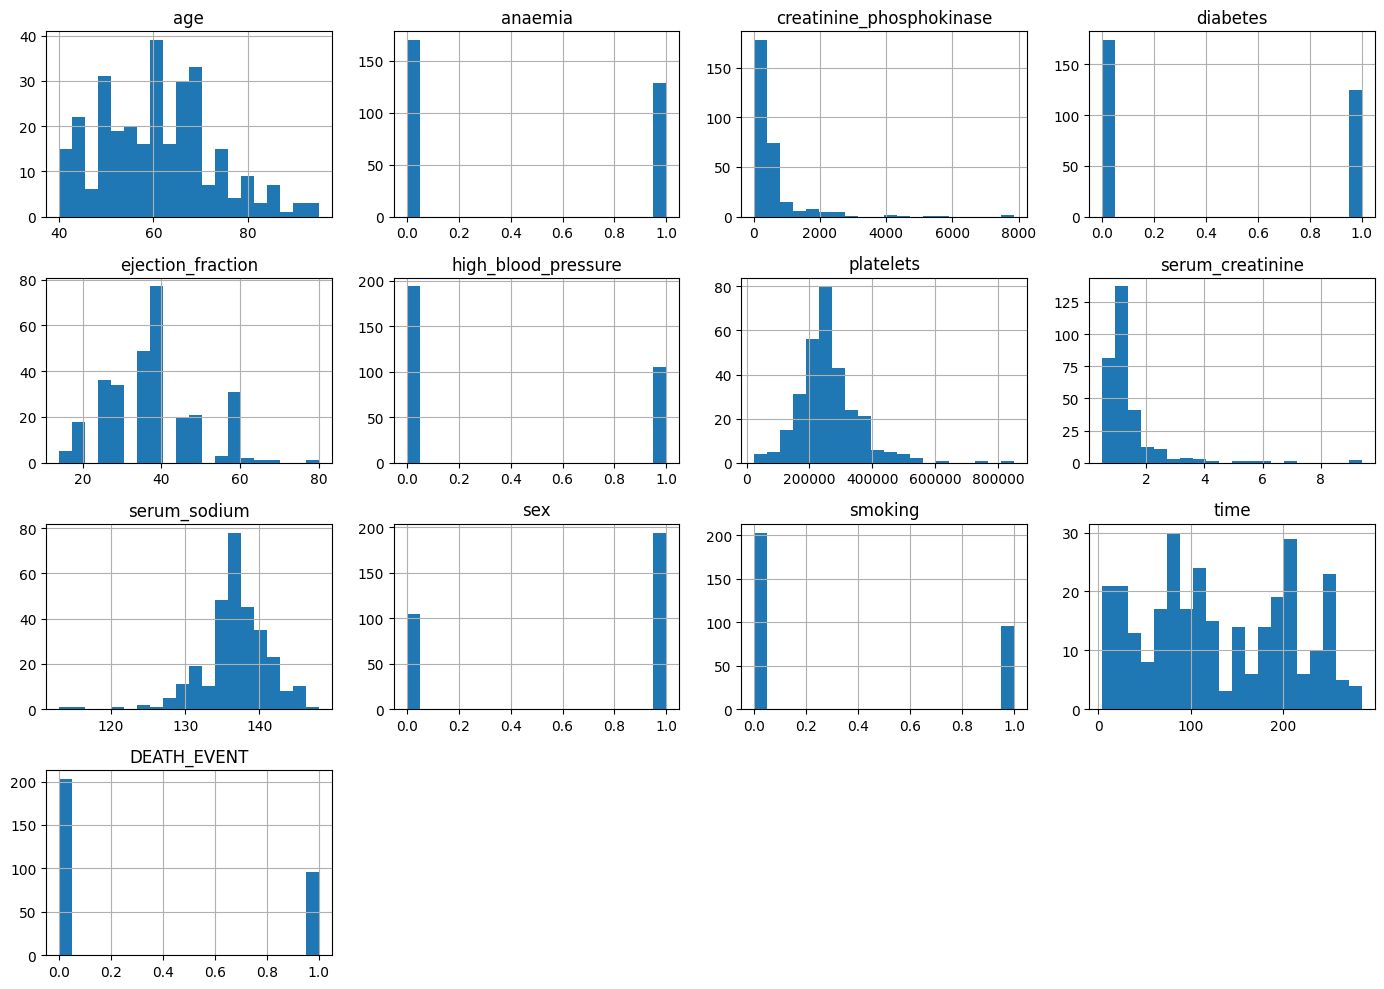

In [81]:
# Histograms for numerical features
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()


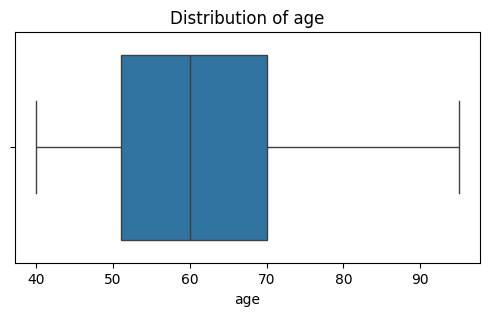

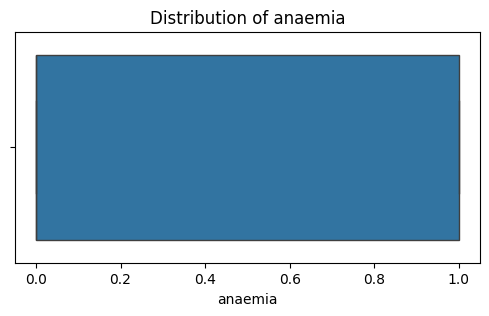

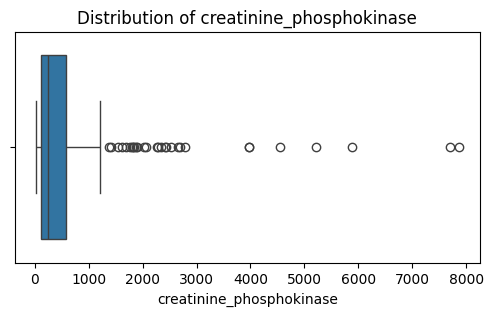

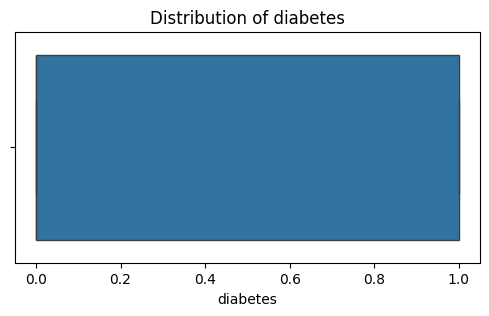

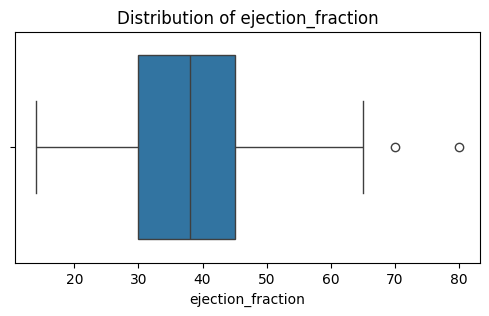

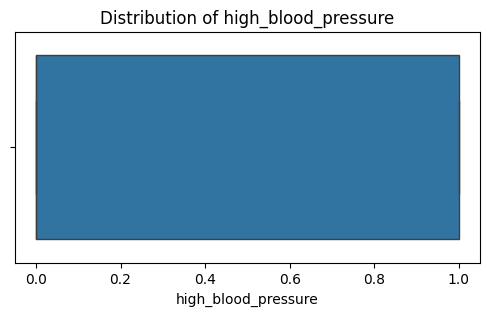

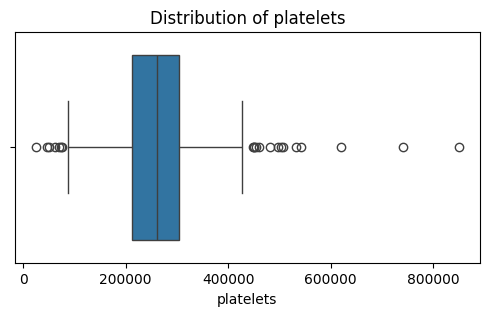

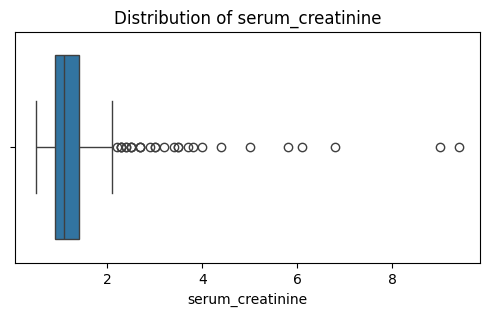

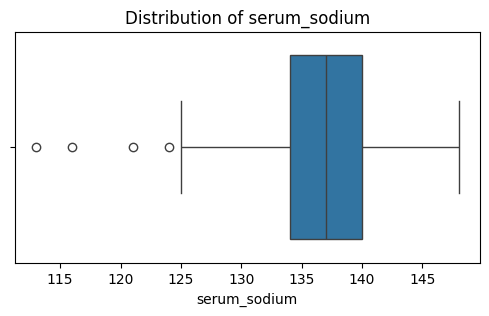

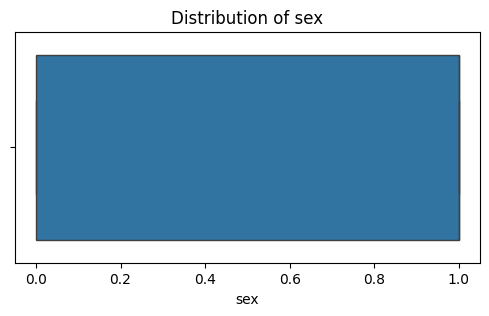

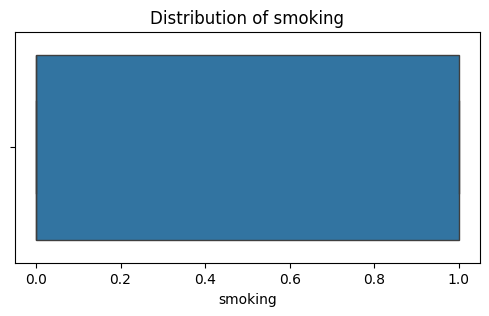

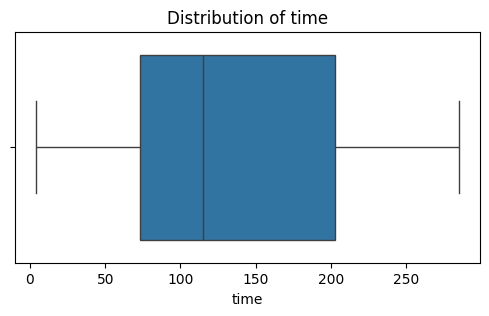

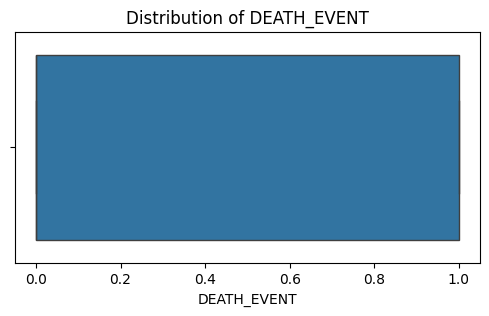

In [82]:
# Boxplots for detecting potential outliers
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

**Outlier Inspection**

Boxplots provide a quick way to identify unusually high or low observations. These points are treated as observations requiring attention rather than automatically being removed.

# 6. Correlation Analysis

The correlation matrix shows the strength and direction of linear relationships between the numerical variables. I use this mainly as an exploratory tool rather than treating correlation as proof of causation.

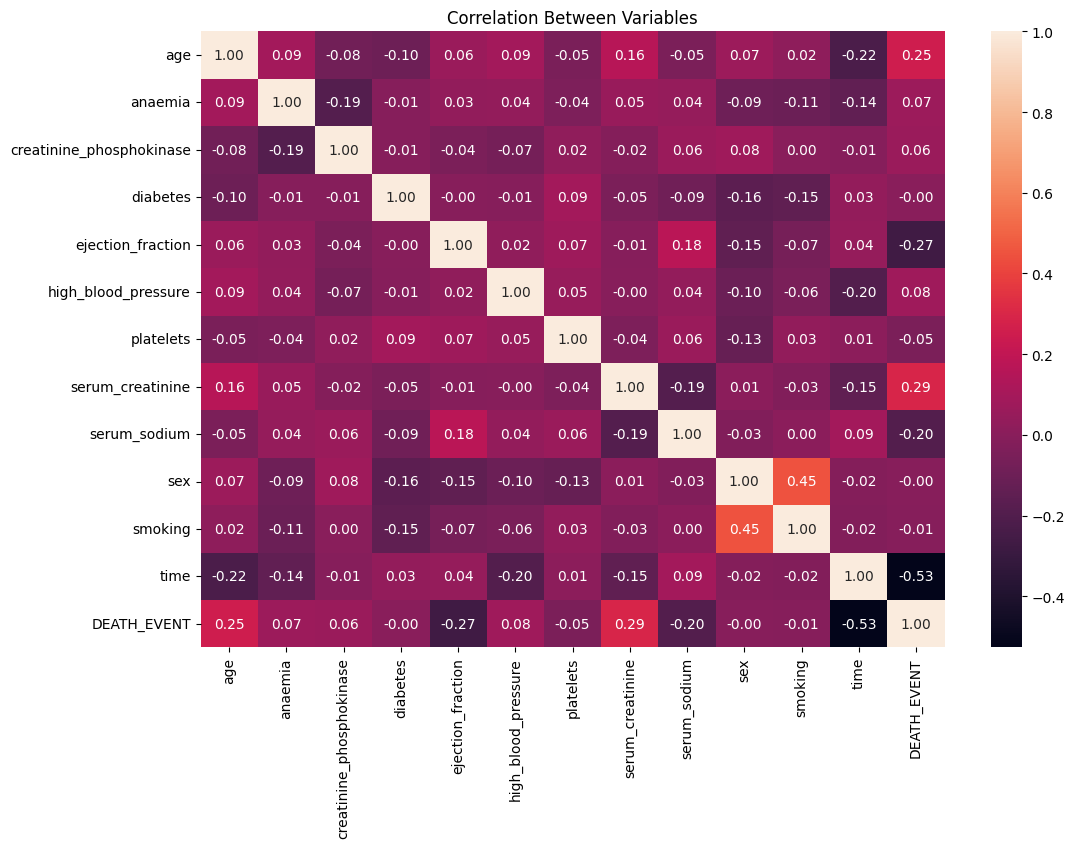

In [83]:
# Correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Between Variables")
plt.show()



### Observation

The correlation matrix gives an initial view of how the numerical variables are related. Some relationships are stronger than others, but these correlations are only used for exploration and are not treated as evidence of causation.

# 7. Feature Comparison by Outcome

I selected a few numerical variables and compared their distributions across the two outcome classes. This helps identify whether there are visible differences between patients with different recorded outcomes.

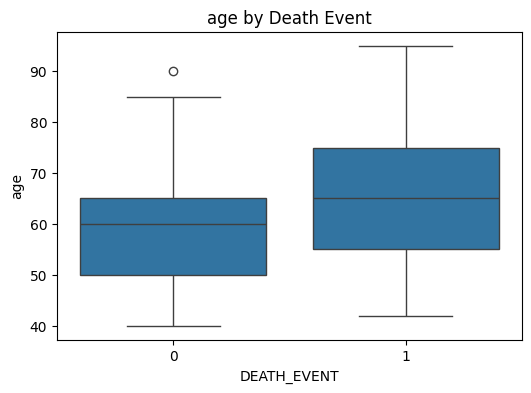

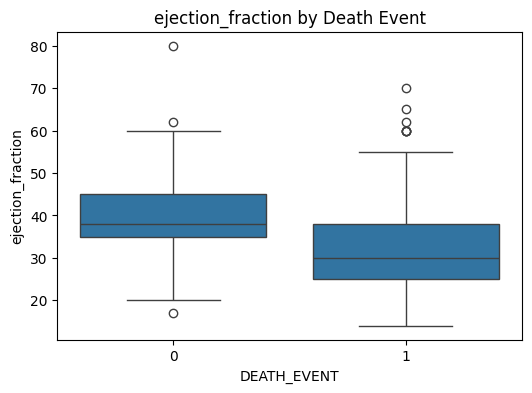

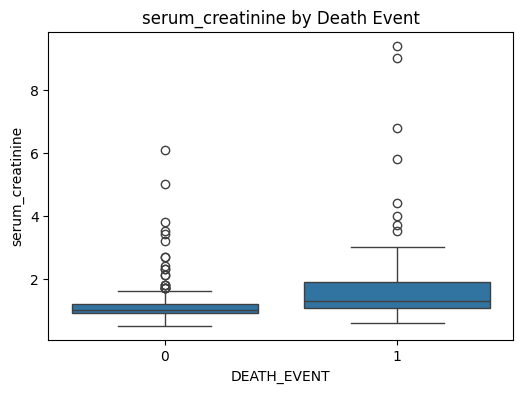

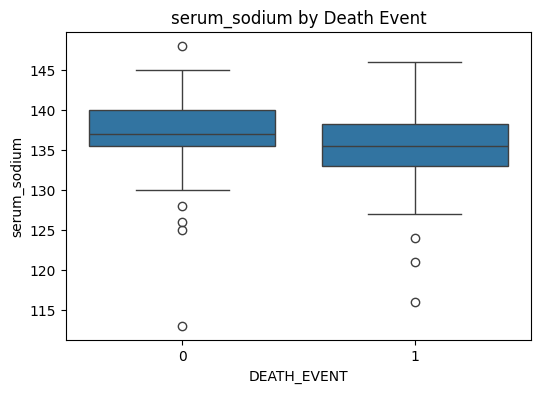

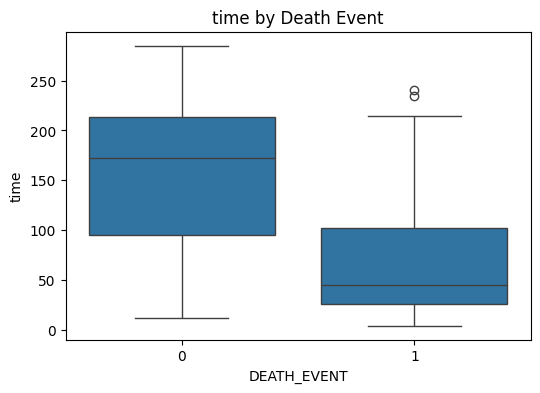

In [84]:
# Compare selected variables against the target
selected_features = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "serum_sodium",
    "time"
]

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="DEATH_EVENT", y=feature)
    plt.title(f"{feature} by Death Event")
    plt.show()

# 8. Preparing Data for Modelling

`DEATH_EVENT` is separated from the predictor variables. The data is then divided into training and testing sets using stratification so that the class distribution is maintained as closely as possible.

The data is divided using an 80/20 stratified split, resulting in 239 training observations and 60 testing observations.

In [85]:
X = df.drop(columns="DEATH_EVENT")
y = df["DEATH_EVENT"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (239, 12)
Testing set: (60, 12)


# 9. Classification Models

Three classification algorithms are compared:

* Logistic Regression — provides a simple linear classification approach.

* Decision Tree — makes predictions through a sequence of decision rules.

* Random Forest — combines multiple decision trees to produce a more robust prediction.

These three models provide different approaches to the classification problem, allowing their performance to be compared on the same test data.

In [86]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

# 10. Model Performance

The models are compared using several evaluation metrics rather than relying only on accuracy. This is particularly useful because the target classes are not equally represented.

Random Forest gives the strongest overall test-set performance, with the highest ROC-AUC among the three models.

In [87]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1 Score": f1_score(y_test, predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

results_df = pd.DataFrame(results)
results_df.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.850000,0.857143,0.631579,0.727273,0.899872
0,Logistic Regression,0.816667,0.785714,0.578947,0.666667,0.858793
1,Decision Tree,0.750000,0.666667,0.421053,0.516129,0.662388


# 11. Cross-Validation

Five-fold stratified cross-validation is used to check whether the model performance remains reasonably consistent across different portions of the dataset.

The five-fold cross-validation gives mean ROC-AUC values of
**0.875** for Logistic Regression, **0.787** for Decision Tree and **0.902** for Random Forest.

In [88]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="roc_auc"
    )

    print(
        f"{name}: "
        f"Mean ROC-AUC = {scores.mean():.3f}, "
        f"Std = {scores.std():.3f}"
    )


Logistic Regression: Mean ROC-AUC = 0.875, Std = 0.032
Decision Tree: Mean ROC-AUC = 0.787, Std = 0.063
Random Forest: Mean ROC-AUC = 0.902, Std = 0.024


## 12. Detailed Evaluation of the Best Model

Random Forest achieved the highest test-set ROC-AUC, so it is selected for more detailed evaluation.

In [89]:
## 12.1 Classification Report
print(classification_report(y_test, predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.85      0.95      0.90        41
           1       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



Selected model: Random Forest
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        41
           1       0.86      0.63      0.73        19

    accuracy                           0.85        60
   macro avg       0.85      0.79      0.81        60
weighted avg       0.85      0.85      0.84        60



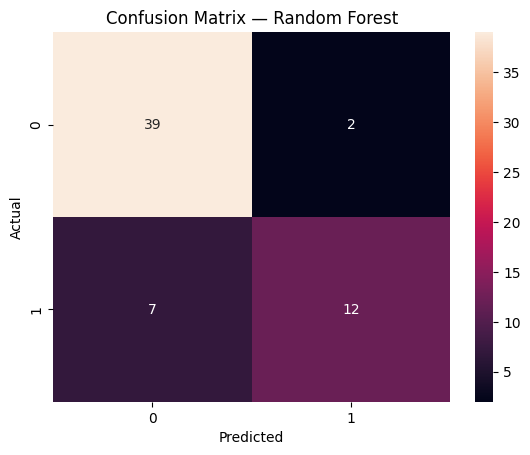

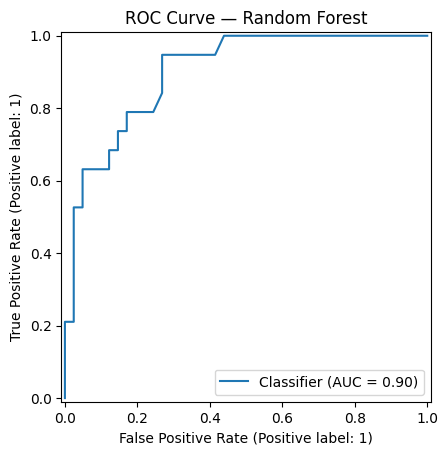

In [90]:
# Detailed evaluation of the Best model

best_name = results_df.sort_values(
    "ROC-AUC",
    ascending=False
).iloc[0]["Model"]

best_model = models[best_name]

best_model.fit(X_train, y_train)

predictions = best_model.predict(X_test)
probabilities = best_model.predict_proba(X_test)[:, 1]

print("Selected model:", best_name)
print(classification_report(y_test, predictions, zero_division=0))

### 12.2 Confusion Matrix

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

### 12.3 ROC Curve

RocCurveDisplay.from_predictions(y_test, probabilities)
plt.title(f"ROC Curve — {best_name}")
plt.show()


### Model Comparison

Random Forest achieved the best overall results among the three models. It recorded the highest ROC-AUC, accuracy, precision, recall and F1-score on the test set.

Logistic Regression gave the second-best results, while the Decision Tree performed lower on the main evaluation measures.

# 13. Conclusion

This analysis followed the main stages of a machine-learning classification workflow, beginning with data inspection and exploratory analysis and ending with model evaluation.

The comparison shows that different algorithms can produce noticeably different results. Looking at several metrics gives a better understanding of the strengths and weaknesses of each model than accuracy alone.

The analysis is limited by the relatively small dataset size and the imbalance between the two outcome classes. Therefore, the results should be treated as an academic machine-learning exercise rather than a clinical prediction system.

## Practice questions

1. Which features appear most strongly associated with the target?
2. Why is stratification useful for this dataset?
3. Why might recall be important in a mortality-related classification task?
4. Compare Logistic Regression, Decision Tree, and Random Forest.
5. What does ROC-AUC tell you that accuracy alone does not?
6. Identify possible limitations of this analysis.
